Bring All data into DataFrames


In [ ]:
import pandas as pd
import os
import glob
import re
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_dir = '/content/drive/MyDrive/WhisperData'

if not os.path.isdir(base_dir):
    raise FileNotFoundError(f"Could not find {base_dir}")


In [ ]:
assess_path = os.path.join(base_dir, 'assess.csv')
asses = pd.read_csv(assess_path)


In [ ]:
rec_paths = sorted(glob.glob(os.path.join(base_dir, 'rec[1-6].csv')))
print("Found rec files:", [os.path.basename(p) for p in rec_paths])
recc_list = [pd.read_csv(p) for p in rec_paths]
recc = pd.concat(recc_list, ignore_index=True)

Found rec files: ['rec1.csv', 'rec2.csv', 'rec3.csv', 'rec4.csv', 'rec5.csv', 'rec6.csv']


In [ ]:
asses.head(5)

,ID,CENTER,FY,SIC,NAICS,STATE,SALES,EMPLOYEES,PLANT_AREA,PRODUCTS,...,W2_plant_cost,W2_plant_usage,W3_plant_cost,W3_plant_usage,W4_plant_cost,W4_plant_usage,W5_plant_cost,W5_plant_usage,W6_plant_cost,W6_plant_usage
0,AM0001,AM,1987,3671.0,NaN,TX,33900000.0,206.0,NaN,MICRO & MINI COMPUTERS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AM0002,AM,1987,2761.0,NaN,TX,25000000.0,156.0,NaN,BUSINESS FORMS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AM0003,AM,1987,3494.0,NaN,TX,15000000.0,200.0,NaN,SAFETY JOINTS & VALVES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AM0004,AM,1987,3713.0,NaN,TX,4200000.0,75.0,NaN,TRUCKS BEDS & TRAILERS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AM0005,AM,1987,2024.0,NaN,TX,12000000.0,39.0,NaN,ICE CREAM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
asses.shape

(22134, 55)

In [ ]:
recc.head(5)

,SUPERID,ID,AR_NUMBER,APPCODE,ARC2,IMPSTATUS,IMPCOST,PSOURCCODE,PCONSERVED,PSOURCONSV,...,QCONSERVED,QSOURCONSV,QSAVED,REBATE,INCREMNTAL,FY,IC_CAPITAL,IC_OTHER,PAYBACK,BPTOOL
0,AM000101,AM0001,1,NaN,2.8114,N,15000.0,E1,NaN,NaN,...,NaN,NaN,NaN,N,N,1987,NaN,NaN,8.205689,NaN
1,AM000102,AM0001,2,NaN,2.7142,N,189.0,E1,7034.0,72.0,...,NaN,NaN,NaN,N,N,1987,NaN,NaN,0.285068,NaN
2,AM000103,AM0001,3,NaN,2.7111,N,398.0,E1,10258.0,105.0,...,NaN,NaN,NaN,N,N,1987,NaN,NaN,0.418947,NaN
3,AM000104,AM0001,4,NaN,2.7447,I,354.0,E1,10844.0,111.0,...,NaN,NaN,NaN,N,N,1987,NaN,NaN,0.650735,NaN
4,AM000105,AM0001,5,NaN,2.7233,N,15.0,E1,4982.0,51.0,...,NaN,NaN,NaN,N,N,1987,NaN,NaN,0.055556,NaN


In [ ]:
recc.shape

(164675, 30)

In [ ]:
asses_filtered = asses[
    (asses["FY"] >= 2018) &
    (asses["STATE"] == "CA")
]



In [ ]:
asses_filtered.shape

(317, 55)

In [ ]:
#Grab all the cost columns
#cost_cols = ['EC_plant_cost', 'ED_plant_cost', 'EF_plant_cost', 'E2_plant_cost', 'E3_plant_cost', 'E4_plant_cost', 'E5_plant_cost', 'E6_plant_cost', 'E7_plant_cost', 'E8_plant_cost', 'E9_plant_cost', 'E10_plant_cost', 'E11_plant_cost', 'E12_plant_cost', 'W0_plant_cost', 'W1_plant_cost', 'W2_plant_cost', 'W3_plant_cost', 'W4_plant_cost', 'W5_plant_cost', 'W6_plant_cost']
costRegEx = re.compile(r".*cost$|^[EW]\d+$")
cost_cols = [c for c in asses_filtered.columns if costRegEx.match(c)]
print(cost_cols)

['EC_plant_cost', 'ED_plant_cost', 'EF_plant_cost', 'E2_plant_cost', 'E3_plant_cost', 'E4_plant_cost', 'E5_plant_cost', 'E6_plant_cost', 'E7_plant_cost', 'E8_plant_cost', 'E9_plant_cost', 'E10_plant_cost', 'E11_plant_cost', 'E12_plant_cost', 'W0_plant_cost', 'W1_plant_cost', 'W2_plant_cost', 'W3_plant_cost', 'W4_plant_cost', 'W5_plant_cost', 'W6_plant_cost']


In [ ]:
asses_filtered["cost"] = asses_filtered[cost_cols].sum(axis=1)

/tmp/ipython-input-13-1351780713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  asses_filtered["cost"] = asses_filtered[cost_cols].sum(axis=1)


In [ ]:
asses_filtered.head(5)

,ID,CENTER,FY,SIC,NAICS,STATE,SALES,EMPLOYEES,PLANT_AREA,PRODUCTS,...,W2_plant_usage,W3_plant_cost,W3_plant_usage,W4_plant_cost,W4_plant_usage,W5_plant_cost,W5_plant_usage,W6_plant_cost,W6_plant_usage,cost
2556,CI0001,CI,2022,3449.0,336413.0,CA,39000000.0,158.0,66336.0,Metal retainer with rubber seals,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,583840.00
2557,CI0002,CI,2022,3429.0,332999.0,CA,100000000.0,389.0,218600.0,Residential Door Locks and Cabinet Hardware Ac...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,332846.00
2558,CI0003,CI,2022,5181.0,488991.0,CA,100000000.0,250.0,573698.0,Beer/Alcohol,...,NaN,NaN,NaN,1122.0,154.836,NaN,NaN,NaN,NaN,411756.00
2559,CI0004,CI,2022,5941.0,451110.0,CA,100000000.0,316.0,180000.0,Outdoor Sporting Goods,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,488760.39
2560,CI0005,CI,2022,3471.0,332813.0,CA,20000000.0,119.0,30600.0,Metal Finishing,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,466502.86


Drop all the usage and cost cols as the cost column is ready aggregated

In [ ]:
asses_filtered.columns

Index(['ID', 'CENTER', 'FY', 'SIC', 'NAICS', 'STATE', 'SALES', 'EMPLOYEES',
       'PLANT_AREA', 'PRODUCTS', 'PRODUNITS', 'PRODLEVEL', 'PRODHOURS',
       'NUMARS', 'EC_plant_cost', 'EC_plant_usage', 'ED_plant_cost',
       'ED_plant_usage', 'EF_plant_cost', 'E2_plant_cost', 'E2_plant_usage',
       'E3_plant_cost', 'E3_plant_usage', 'E4_plant_cost', 'E4_plant_usage',
       'E5_plant_cost', 'E5_plant_usage', 'E6_plant_cost', 'E6_plant_usage',
       'E7_plant_cost', 'E7_plant_usage', 'E8_plant_cost', 'E8_plant_usage',
       'E9_plant_cost', 'E9_plant_usage', 'E10_plant_cost', 'E10_plant_usage',
       'E11_plant_cost', 'E11_plant_usage', 'E12_plant_cost',
       'E12_plant_usage', 'W0_plant_cost', 'W0_plant_usage', 'W1_plant_cost',
       'W1_plant_usage', 'W2_plant_cost', 'W2_plant_usage', 'W3_plant_cost',
       'W3_plant_usage', 'W4_plant_cost', 'W4_plant_usage', 'W5_plant_cost',
       'W5_plant_usage', 'W6_plant_cost', 'W6_plant_usage', 'cost'],
      dtype='object')

In [ ]:
cols_idx = list(asses_filtered.columns)
start_idx = cols_idx.index("EC_plant_cost")
end_idx   = cols_idx.index("W6_plant_usage")
costUse_cols_to_drop = cols_idx[start_idx : end_idx + 1]
print(f"Dropping {len(costUse_cols_to_drop)} columns:")
for c in costUse_cols_to_drop:
    print("  •", c)


Dropping 41 columns:
  • EC_plant_cost
  • EC_plant_usage
  • ED_plant_cost
  • ED_plant_usage
  • EF_plant_cost
  • E2_plant_cost
  • E2_plant_usage
  • E3_plant_cost
  • E3_plant_usage
  • E4_plant_cost
  • E4_plant_usage
  • E5_plant_cost
  • E5_plant_usage
  • E6_plant_cost
  • E6_plant_usage
  • E7_plant_cost
  • E7_plant_usage
  • E8_plant_cost
  • E8_plant_usage
  • E9_plant_cost
  • E9_plant_usage
  • E10_plant_cost
  • E10_plant_usage
  • E11_plant_cost
  • E11_plant_usage
  • E12_plant_cost
  • E12_plant_usage
  • W0_plant_cost
  • W0_plant_usage
  • W1_plant_cost
  • W1_plant_usage
  • W2_plant_cost
  • W2_plant_usage
  • W3_plant_cost
  • W3_plant_usage
  • W4_plant_cost
  • W4_plant_usage
  • W5_plant_cost
  • W5_plant_usage
  • W6_plant_cost
  • W6_plant_usage


In [ ]:
asses_filtered = asses_filtered.drop(columns=costUse_cols_to_drop)

print("\nRemaining columns:")
print(asses_filtered.columns.tolist())



Remaining columns:
['ID', 'CENTER', 'FY', 'SIC', 'NAICS', 'STATE', 'SALES', 'EMPLOYEES', 'PLANT_AREA', 'PRODUCTS', 'PRODUNITS', 'PRODLEVEL', 'PRODHOURS', 'NUMARS', 'cost']


In [ ]:
asses_filtered.head(5)

,ID,CENTER,FY,SIC,NAICS,STATE,SALES,EMPLOYEES,PLANT_AREA,PRODUCTS,PRODUNITS,PRODLEVEL,PRODHOURS,NUMARS,cost
2556,CI0001,CI,2022,3449.0,336413.0,CA,39000000.0,158.0,66336.0,Metal retainer with rubber seals,1.0,186553.0,5616.0,7,583840.00
2557,CI0002,CI,2022,3429.0,332999.0,CA,100000000.0,389.0,218600.0,Residential Door Locks and Cabinet Hardware Ac...,1.0,1000000.0,3060.0,9,332846.00
2558,CI0003,CI,2022,5181.0,488991.0,CA,100000000.0,250.0,573698.0,Beer/Alcohol,1.0,10000000.0,7488.0,8,411756.00
2559,CI0004,CI,2022,5941.0,451110.0,CA,100000000.0,316.0,180000.0,Outdoor Sporting Goods,NaN,1.0,4004.0,6,488760.39
2560,CI0005,CI,2022,3471.0,332813.0,CA,20000000.0,119.0,30600.0,Metal Finishing,1.0,50000.0,5304.0,10,466502.86


In [ ]:
asses_filtered.shape

(317, 15)

In [ ]:
sic_counts   = asses_filtered['SIC'].value_counts()
naics_counts = asses_filtered['NAICS'].value_counts()

print("SIC code counts")
print(sic_counts.to_string(), "\n")

print("NAICS code counts")
print(naics_counts.to_string(), "\n")


SIC code counts
SIC
2084.0    16
4952.0    14
3089.0    13
3599.0    13
3444.0    11
3728.0    11
3479.0     9
2099.0     8
2082.0     7
2068.0     7
2026.0     7
3471.0     6
3679.0     6
3398.0     5
3674.0     4
2836.0     4
3411.0     4
3841.0     4
3499.0     4
2051.0     4
2752.0     4
3069.0     4
2037.0     3
2834.0     3
8322.0     3
2899.0     3
2759.0     3
3691.0     3
8211.0     3
3843.0     2
3571.0     2
3823.0     2
3429.0     2
2821.0     2
2023.0     2
3211.0     2
3231.0     2
2521.0     2
3229.0     2
3645.0     2
4941.0     2
2067.0     2
2022.0     2
3357.0     2
3085.0     2
2013.0     2
2671.0     2
2024.0     2
3999.0     2
2493.0     2
3272.0     2
2064.0     2
2033.0     2
3399.0     2
4222.0     2
7218.0     2
3449.0     1
5941.0     1
5181.0     1
2675.0     1
8711.0     1
3084.0     1
3489.0     1
3564.0     1
5064.0     1
3592.0     1
2541.0     1
3083.0     1
3498.0     1
2841.0     1
3259.0     1
3495.0     1
2041.0     1
3251.0     1
2952.0     1
3253.

In [ ]:
print("Top 5 SIC codes")
print(sic_counts.head(5).to_string(), "\n")

print("Top 5 NAICS codes")
print(naics_counts.head(5).to_string(), "\n")

Top 5 SIC codes
SIC
2084.0    16
4952.0    14
3089.0    13
3599.0    13
3444.0    11 

Top 5 NAICS codes
NAICS
312130.0    16
221320.0    14
336413.0    12
326199.0    12
332710.0    12 



In [ ]:
sic_lookup = pd.read_csv(os.path.join(base_dir, 'sic-codes.csv'))
sic_lookup.head(5)

,Division,Major Group,Industry Group,SIC,Description
0,A,1,11,111,Wheat
1,A,1,11,112,Rice
2,A,1,11,115,Corn
3,A,1,11,116,Soybeans
4,A,1,11,119,"Cash Grains, Not Elsewhere Classified"


In [ ]:
top10_sic = (
    asses_filtered["SIC"]
    .value_counts()
    .head(10)
    .rename_axis("SIC")
    .reset_index(name="count")
)
top10_sic#Dataframe of SIC and Counts

,SIC,count
0,2084.0,16
1,4952.0,14
2,3089.0,13
3,3599.0,13
4,3444.0,11
5,3728.0,11
6,3479.0,9
7,2099.0,8
8,2082.0,7
9,2068.0,7


In [ ]:
top10SIC = top10_sic.merge(sic_lookup, on="SIC", how="left")#Tables Joined on SIC
top10SIC#After merge with the lookup

,SIC,count,Division,Major Group,Industry Group,Description
0,2084.0,16,D,20,208,"Wines, Brandy, and Brandy Spirits"
1,4952.0,14,E,49,495,Sewerage Systems
2,3089.0,13,D,30,308,"Plastics Products, Not Elsewhere Classified"
3,3599.0,13,D,35,359,Industrial and Commercial Machinery and Equipm...
4,3444.0,11,D,34,344,Sheet Metal Work
5,3728.0,11,D,37,372,"Aircraft Parts and Auxiliary Equipment, Not El..."
6,3479.0,9,D,34,347,"Coating, Engraving, and Allied Services, Not E..."
7,2099.0,8,D,20,209,"Food Preparations, Not Elsewhere Classified"
8,2082.0,7,D,20,208,Malt Beverages
9,2068.0,7,D,20,206,Salted and Roasted Nuts and Seeds


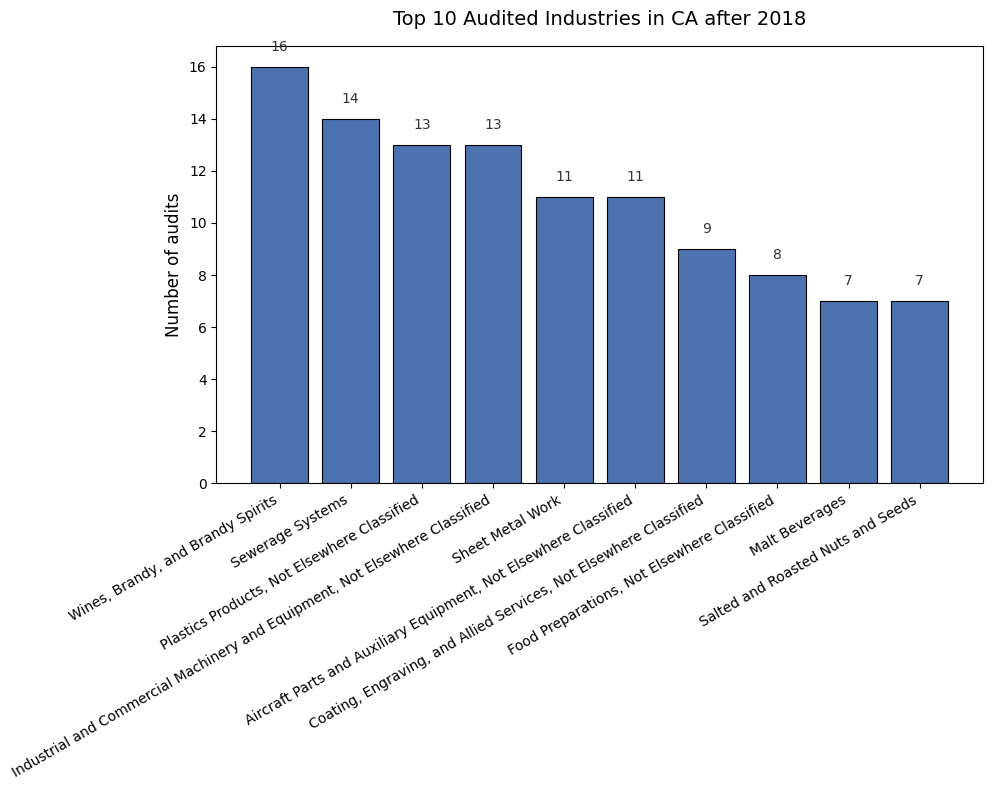

In [ ]:
plt.figure(figsize=(10, 8))
bars = plt.bar(
    top10SIC["Description"],
    top10SIC["count"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#333333"
    )

# Tidy up axes and labels
plt.title("Top 10 Audited Industries in CA after 2018", fontsize=14, pad=15)
plt.ylabel("Number of audits", fontsize=12)
plt.xticks(
    rotation=30,
    ha="right",
    fontsize=10,
)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Assessing SIC over Cost

In [ ]:
sic_aggregated_cost = (
    asses_filtered
      .groupby("SIC", as_index=False)   # keep SIC as a column
      .agg(total_cost=("cost", "sum")) # sum up the cost column
)

In [ ]:
sic_aggregated_cost

,SIC,total_cost
0,2013.0,306311.00
1,2022.0,1673591.00
2,2023.0,6227630.00
3,2024.0,1337371.00
4,2026.0,15837080.82
...,...,...
128,7699.0,2243881.00
129,7812.0,4723984.21
130,8211.0,908530.00
131,8322.0,742856.00


In [ ]:
top10_sic_aggregated_cost = sic_aggregated_cost.sort_values("total_cost", ascending=False).head(10)
top10_sic_aggregated_cost

,SIC,total_cost
123,4952.0,22752287.46
4,2026.0,15837080.82
19,2084.0,10812923.22
22,2099.0,9969533.23
5,2033.0,9588561.00
17,2068.0,8562310.77
55,3085.0,8459493.00
112,3728.0,7347326.00
18,2082.0,7103088.00
56,3089.0,7061863.00


In [ ]:
top10_sic_aggregated_cost_joined_sic = top10_sic_aggregated_cost.merge(sic_lookup, on="SIC", how="left")
top10_sic_aggregated_cost_joined_sic

,SIC,total_cost,Division,Major Group,Industry Group,Description
0,4952.0,22752287.46,E,49,495,Sewerage Systems
1,2026.0,15837080.82,D,20,202,Fluid Milk
2,2084.0,10812923.22,D,20,208,"Wines, Brandy, and Brandy Spirits"
3,2099.0,9969533.23,D,20,209,"Food Preparations, Not Elsewhere Classified"
4,2033.0,9588561.00,D,20,203,"Canned Fruits, Vegetables, Preserves, Jams, an..."
5,2068.0,8562310.77,D,20,206,Salted and Roasted Nuts and Seeds
6,3085.0,8459493.00,D,30,308,Plastics Bottles
7,3728.0,7347326.00,D,37,372,"Aircraft Parts and Auxiliary Equipment, Not El..."
8,2082.0,7103088.00,D,20,208,Malt Beverages
9,3089.0,7061863.00,D,30,308,"Plastics Products, Not Elsewhere Classified"


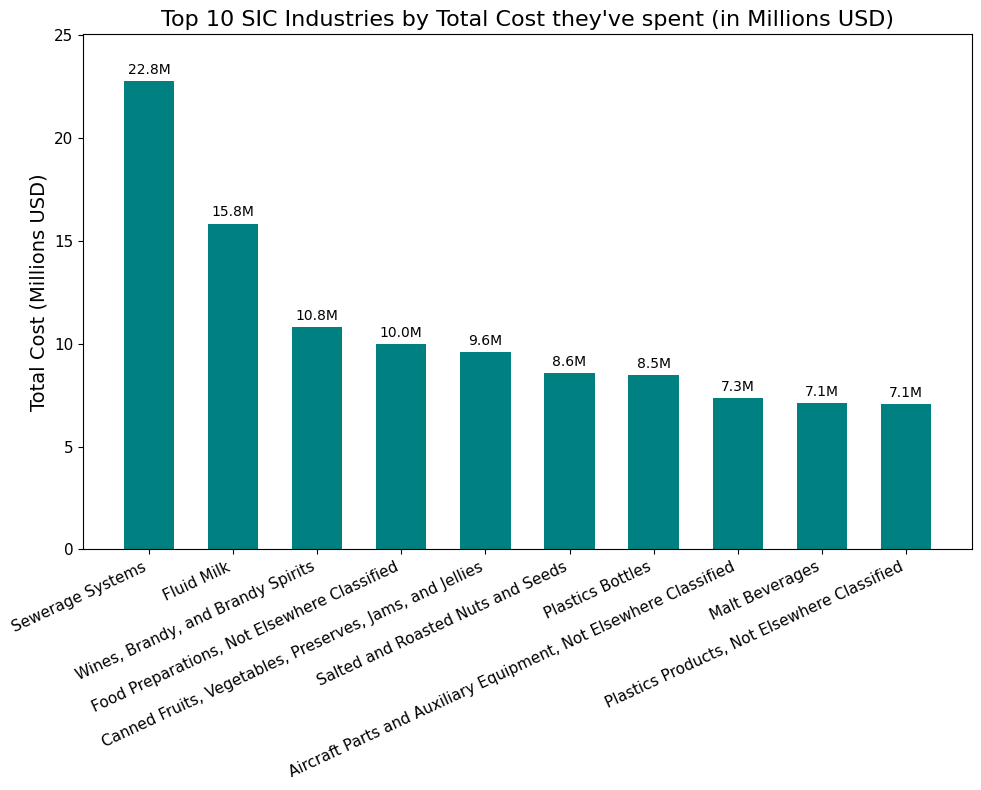

In [ ]:
labels = top10_sic_aggregated_cost_joined_sic["Description"]
costs_m = top10_sic_aggregated_cost_joined_sic["total_cost"] / 1e6  # millions

plt.figure(figsize=(10, 8))
bars = plt.bar(labels, costs_m, color="teal", width=0.6)

# 3. Formatting
plt.title("Top 10 SIC Industries by Total Cost they've spent (in Millions USD)", fontsize=16)
plt.ylabel("Total Cost (Millions USD)", fontsize=14)
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, costs_m.max() * 1.1)  # add a little headroom for annotations

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.2,                     # slightly above the bar
        f"{h:.1f}M",                 # one decimal place
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


In [ ]:
sic_summary = (
    sic_aggregated_cost
    .merge(sic_counts, on="SIC", how="inner")
)

sic_summary["avg_cost_per_audit"] = sic_summary["total_cost"] / sic_summary["count"]
sic_summary

,SIC,total_cost,count,avg_cost_per_audit
0,2013.0,306311.00,2,1.531555e+05
1,2022.0,1673591.00,2,8.367955e+05
2,2023.0,6227630.00,2,3.113815e+06
3,2024.0,1337371.00,2,6.686855e+05
4,2026.0,15837080.82,7,2.262440e+06
...,...,...,...,...
128,7699.0,2243881.00,1,2.243881e+06
129,7812.0,4723984.21,1,4.723984e+06
130,8211.0,908530.00,3,3.028433e+05
131,8322.0,742856.00,3,2.476187e+05


In [ ]:
top10_SIC_AVG = (
    sic_summary
    .sort_values("avg_cost_per_audit", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_SIC_AVG = top10_SIC_AVG.merge(sic_lookup, on="SIC", how="left")
top10_SIC_AVG

,SIC,total_cost,count,avg_cost_per_audit,Division,Major Group,Industry Group,Description
0,2033.0,9588561.00,2,4.794280e+06,D,20,203,"Canned Fruits, Vegetables, Preserves, Jams, an..."
1,7812.0,4723984.21,1,4.723984e+06,I,78,781,Motion Picture and Video Tape Production
2,3085.0,8459493.00,2,4.229746e+06,D,30,308,Plastics Bottles
3,2023.0,6227630.00,2,3.113815e+06,D,20,202,"Dry, Condensed, and Evaporated Dairy Products"
4,2673.0,2926207.00,1,2.926207e+06,D,26,267,"Plastics, Foil, and Coated Paper Bags"
5,4222.0,5067702.00,2,2.533851e+06,E,42,422,Refrigerated Warehousing and Storage
6,3452.0,2335614.00,1,2.335614e+06,D,34,345,"Bolts, Nuts, Screws, Rivets, and Washers"
7,2821.0,4598432.60,2,2.299216e+06,D,28,282,"Plastics Materials, Synthetic Resins, and Nonv..."
8,2026.0,15837080.82,7,2.262440e+06,D,20,202,Fluid Milk
9,2041.0,2257937.90,1,2.257938e+06,D,20,204,Flour and Other Grain Mill Products


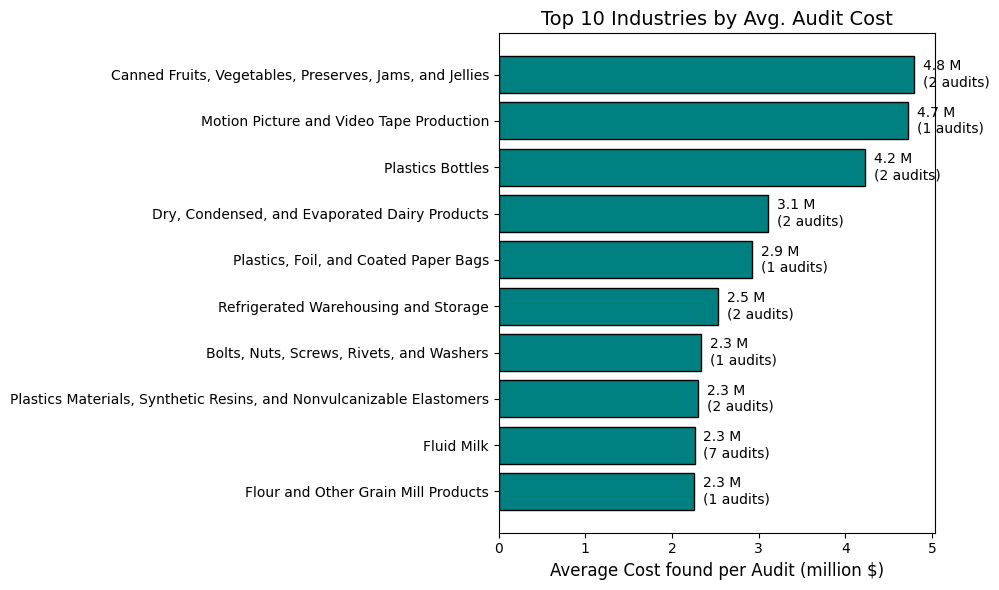

In [ ]:
plt.figure(figsize=(10, 6))
bars = plt.barh(
    top10_SIC_AVG["Description"],
    top10_SIC_AVG["avg_cost_per_audit"] / 1e6,
    color="teal",
    edgecolor="k"
)

for bar, (_, row) in zip(bars, top10_SIC_AVG.iterrows()):
    avg_m = bar.get_width()
    count = int(row["count"])
    plt.text(
        avg_m + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{avg_m:0.1f} M\n({count} audits)",
        va="center",
        fontsize=10
    )

plt.title("Top 10 Industries by Avg. Audit Cost", fontsize=14)
plt.xlabel("Average Cost found per Audit (million $)", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Mapping asses_filtered to recc

In [ ]:
asses_rec = recc[recc['ID'].isin(asses_filtered['ID'])].copy()

print("\nShape of asses_rec:", asses_rec.shape)

asses_filtered_ids = set(asses_filtered['ID'].unique())
asses_rec_ids = set(asses_rec['ID'].unique())

# Check if all IDs from asses_filtered are present in asses_rec
if asses_filtered_ids.issubset(asses_rec_ids):
    print("All IDs from asses_filtered are present in asses_rec.")
else:
    print("Some IDs from asses_filtered are NOT present in asses_rec.")
    missing_ids = asses_filtered_ids - asses_rec_ids
    print(f"Missing IDs: {missing_ids}")


Shape of asses_rec: (2294, 30)
All IDs from asses_filtered are present in asses_rec.


In [ ]:
# Display the head of the new dataframe
asses_rec.head(10)

,SUPERID,ID,AR_NUMBER,APPCODE,ARC2,IMPSTATUS,IMPCOST,PSOURCCODE,PCONSERVED,PSOURCONSV,...,QCONSERVED,QSOURCONSV,QSAVED,REBATE,INCREMNTAL,FY,IC_CAPITAL,IC_OTHER,PAYBACK,BPTOOL
19844,CI000101,CI0001,1,NaN,2.4236,I,750.0,EC,236360.0,NaN,...,NaN,NaN,NaN,N,N,2022,150.0,600.0,NaN,AM+
19845,CI000102,CI0001,2,NaN,2.2437,N,3500.0,EC,82148.0,NaN,...,NaN,NaN,NaN,N,N,2022,3000.0,500.0,NaN,PHAST
19846,CI000103,CI0001,3,NaN,2.1122,N,6000.0,EC,89856.0,NaN,...,NaN,NaN,NaN,N,N,2022,6000.0,NaN,NaN,MEASUR
19847,CI000104,CI0001,4,NaN,2.3132,N,100.0,ED,96.0,NaN,...,NaN,NaN,NaN,N,N,2022,100.0,NaN,NaN,none
19848,CI000105,CI0001,5,NaN,2.4226,N,5000.0,EC,35087.0,NaN,...,NaN,NaN,NaN,N,N,2022,5000.0,NaN,NaN,AM+
19849,CI000106,CI0001,6,NaN,2.4231,N,25.0,EC,8081.0,NaN,...,NaN,NaN,NaN,N,N,2022,NaN,25.0,NaN,AM+
19850,CI000107,CI0001,7,NaN,2.7134,N,1440.0,EC,6050.0,NaN,...,NaN,NaN,98.1,N,N,2022,1440.0,NaN,NaN,none
19851,CI000201,CI0002,1,NaN,2.8227,N,80000.0,E3,1.0,NaN,...,NaN,NaN,NaN,Y,N,2022,80000.0,NaN,NaN,none
19852,CI000202,CI0002,2,NaN,2.7491,N,24600.0,EC,135486.0,NaN,...,NaN,NaN,NaN,N,N,2022,24600.0,NaN,NaN,none
19853,CI000203,CI0002,3,NaN,2.4236,N,1800.0,EC,90329.0,NaN,...,NaN,NaN,NaN,N,Y,2022,NaN,1800.0,NaN,AM+


In [ ]:
# Aggregate the specified columns
asses_rec['TOTAL_SAVINGS'] = asses_rec[['PSAVED', 'SSAVED','TSAVED', 'QSAVED']].sum(axis=1)

print("\nAsses_rec head with TOTAL_SAVINGS:")
asses_rec.head()


Asses_rec head with TOTAL_SAVINGS:


,SUPERID,ID,AR_NUMBER,APPCODE,ARC2,IMPSTATUS,IMPCOST,PSOURCCODE,PCONSERVED,PSOURCONSV,...,QSOURCONSV,QSAVED,REBATE,INCREMNTAL,FY,IC_CAPITAL,IC_OTHER,PAYBACK,BPTOOL,TOTAL_SAVINGS
19844,CI000101,CI0001,1,NaN,2.4236,I,750.0,EC,236360.0,NaN,...,NaN,NaN,N,N,2022,150.0,600.0,NaN,AM+,27056.0
19845,CI000102,CI0001,2,NaN,2.2437,N,3500.0,EC,82148.0,NaN,...,NaN,NaN,N,N,2022,3000.0,500.0,NaN,PHAST,16299.0
19846,CI000103,CI0001,3,NaN,2.1122,N,6000.0,EC,89856.0,NaN,...,NaN,NaN,N,N,2022,6000.0,NaN,NaN,MEASUR,5122.0
19847,CI000104,CI0001,4,NaN,2.3132,N,100.0,ED,96.0,NaN,...,NaN,NaN,N,N,2022,100.0,NaN,NaN,none,2151.0
19848,CI000105,CI0001,5,NaN,2.4226,N,5000.0,EC,35087.0,NaN,...,NaN,NaN,N,N,2022,5000.0,NaN,NaN,AM+,2000.0


In [ ]:
cols_to_drop_savings = ['PSAVED', 'SSAVED', 'TSAVED', 'QSAVED']
asses_rec = asses_rec.drop(columns=cols_to_drop_savings, errors='ignore')

total_savings_col = asses_rec.pop('TOTAL_SAVINGS')
current_cols = asses_rec.columns.tolist()
insert_pos = min(10, len(current_cols))
current_cols = current_cols[:insert_pos] + [total_savings_col.name] + current_cols[insert_pos:]

asses_rec['TOTAL_SAVINGS'] = total_savings_col
asses_rec = asses_rec[current_cols]

print("\nColumns after dropping and reordering:")
print(asses_rec.columns.tolist())

asses_rec.head(10)


Columns after dropping and reordering:
['SUPERID', 'ID', 'AR_NUMBER', 'APPCODE', 'ARC2', 'IMPSTATUS', 'IMPCOST', 'PSOURCCODE', 'PCONSERVED', 'PSOURCONSV', 'TOTAL_SAVINGS', 'SSOURCCODE', 'SCONSERVED', 'SSOURCONSV', 'TSOURCCODE', 'TCONSERVED', 'TSOURCONSV', 'QSOURCCODE', 'QCONSERVED', 'QSOURCONSV', 'REBATE', 'INCREMNTAL', 'FY', 'IC_CAPITAL', 'IC_OTHER', 'PAYBACK', 'BPTOOL']


,SUPERID,ID,AR_NUMBER,APPCODE,ARC2,IMPSTATUS,IMPCOST,PSOURCCODE,PCONSERVED,PSOURCONSV,...,QSOURCCODE,QCONSERVED,QSOURCONSV,REBATE,INCREMNTAL,FY,IC_CAPITAL,IC_OTHER,PAYBACK,BPTOOL
19844,CI000101,CI0001,1,NaN,2.4236,I,750.0,EC,236360.0,NaN,...,NaN,NaN,NaN,N,N,2022,150.0,600.0,NaN,AM+
19845,CI000102,CI0001,2,NaN,2.2437,N,3500.0,EC,82148.0,NaN,...,NaN,NaN,NaN,N,N,2022,3000.0,500.0,NaN,PHAST
19846,CI000103,CI0001,3,NaN,2.1122,N,6000.0,EC,89856.0,NaN,...,NaN,NaN,NaN,N,N,2022,6000.0,NaN,NaN,MEASUR
19847,CI000104,CI0001,4,NaN,2.3132,N,100.0,ED,96.0,NaN,...,NaN,NaN,NaN,N,N,2022,100.0,NaN,NaN,none
19848,CI000105,CI0001,5,NaN,2.4226,N,5000.0,EC,35087.0,NaN,...,NaN,NaN,NaN,N,N,2022,5000.0,NaN,NaN,AM+
19849,CI000106,CI0001,6,NaN,2.4231,N,25.0,EC,8081.0,NaN,...,NaN,NaN,NaN,N,N,2022,NaN,25.0,NaN,AM+
19850,CI000107,CI0001,7,NaN,2.7134,N,1440.0,EC,6050.0,NaN,...,R4,NaN,NaN,N,N,2022,1440.0,NaN,NaN,none
19851,CI000201,CI0002,1,NaN,2.8227,N,80000.0,E3,1.0,NaN,...,NaN,NaN,NaN,Y,N,2022,80000.0,NaN,NaN,none
19852,CI000202,CI0002,2,NaN,2.7491,N,24600.0,EC,135486.0,NaN,...,NaN,NaN,NaN,N,N,2022,24600.0,NaN,NaN,none
19853,CI000203,CI0002,3,NaN,2.4236,N,1800.0,EC,90329.0,NaN,...,NaN,NaN,NaN,N,Y,2022,NaN,1800.0,NaN,AM+


In [ ]:
asses_rec_aggregated = asses_rec.groupby('ID', as_index=False)[['TOTAL_SAVINGS',"IMPCOST"]].sum()
asses_rec_aggregated.rename(columns={ "IMPCOST": "TOTAL_RECC_IMP_COST","TOTAL_SAVINGS": "TOTAL_RECC_SAVINGS" }, inplace=True)
print("\nAggregated asses_rec by ID:")
asses_rec_aggregated.head(10)


Aggregated asses_rec by ID:


,ID,TOTAL_RECC_SAVINGS,TOTAL_RECC_IMP_COST
0,CI0001,55078.85,16815.0
1,CI0002,104906.09,150582.0
2,CI0003,154739.00,215926.0
3,CI0004,87712.00,316222.0
4,CI0005,82270.00,77771.0
5,CI0006,112736.00,240297.0
6,CI0007,75791.00,21296.0
7,CI0008,246286.00,525828.0
8,CI0009,97871.00,261083.0
9,CI0010,45802.00,140345.0


In [ ]:
asses_filtered_with_savings = asses_filtered.merge(asses_rec_aggregated, on='ID', how='left')

# Fill any potential NaN values in TOTAL_SAVINGS if an ID in asses_filtered was not in asses_rec
asses_filtered_with_savings['TOTAL_RECC_SAVINGS'] = asses_filtered_with_savings['TOTAL_RECC_SAVINGS'].fillna(0)
asses_filtered_with_savings.rename(columns={ "cost":"BUILDING_POWER_COSTS" }, inplace=True)
print("\nAsses_filtered merged with aggregated TOTAL_SAVINGS:")
asses_filtered_with_savings.head(10)


Asses_filtered merged with aggregated TOTAL_SAVINGS:


,ID,CENTER,FY,SIC,NAICS,STATE,SALES,EMPLOYEES,PLANT_AREA,PRODUCTS,PRODUNITS,PRODLEVEL,PRODHOURS,NUMARS,BUILDING_POWER_COSTS,TOTAL_RECC_SAVINGS,TOTAL_RECC_IMP_COST
0,CI0001,CI,2022,3449.0,336413.0,CA,39000000.0,158.0,66336.0,Metal retainer with rubber seals,1.0,186553.0,5616.0,7,583840.00,55078.85,16815.0
1,CI0002,CI,2022,3429.0,332999.0,CA,100000000.0,389.0,218600.0,Residential Door Locks and Cabinet Hardware Ac...,1.0,1000000.0,3060.0,9,332846.00,104906.09,150582.0
2,CI0003,CI,2022,5181.0,488991.0,CA,100000000.0,250.0,573698.0,Beer/Alcohol,1.0,10000000.0,7488.0,8,411756.00,154739.00,215926.0
3,CI0004,CI,2022,5941.0,451110.0,CA,100000000.0,316.0,180000.0,Outdoor Sporting Goods,NaN,1.0,4004.0,6,488760.39,87712.00,316222.0
4,CI0005,CI,2022,3471.0,332813.0,CA,20000000.0,119.0,30600.0,Metal Finishing,1.0,50000.0,5304.0,10,466502.86,82270.00,77771.0
5,CI0006,CI,2022,3471.0,332813.0,CA,20000000.0,150.0,170000.0,Metal Finishing,1.0,50000.0,6240.0,7,1713000.50,112736.00,240297.0
6,CI0007,CI,2023,3679.0,334418.0,CA,40000000.0,135.0,65000.0,PCBA and Electro-Mechanical Products,1.0,40000000.0,2000.0,8,226690.00,75791.00,21296.0
7,CI0008,CI,2023,8322.0,624120.0,CA,100000.0,1.0,89359.0,Community Center,NaN,1.0,5096.0,7,323640.00,246286.00,525828.0
8,CI0009,CI,2023,3564.0,333413.0,CA,25000000.0,120.0,125000.0,Filters,1.0,4500000.0,4680.0,7,149565.84,97871.00,261083.0
9,CI0010,CI,2023,5064.0,423620.0,CA,6000000.0,35.0,94176.0,Electronics Recycling,1.0,480000.0,2210.0,7,95024.81,45802.00,140345.0


In [ ]:
keep = [
    "ID",
    "CENTER",
    "FY",
    "SIC","NAICS","STATE","SALES","EMPLOYEES","PLANT_AREA","PRODUCTS"
    "BUILDING_POWER_COSTS",
    "TOTAL_RECC_SAVINGS",
    "TOTAL_RECC_IMP_COST",
]

In [ ]:
print("Shape of merged dataframe:", asses_filtered_with_savings.shape)

Shape of merged dataframe: (317, 17)


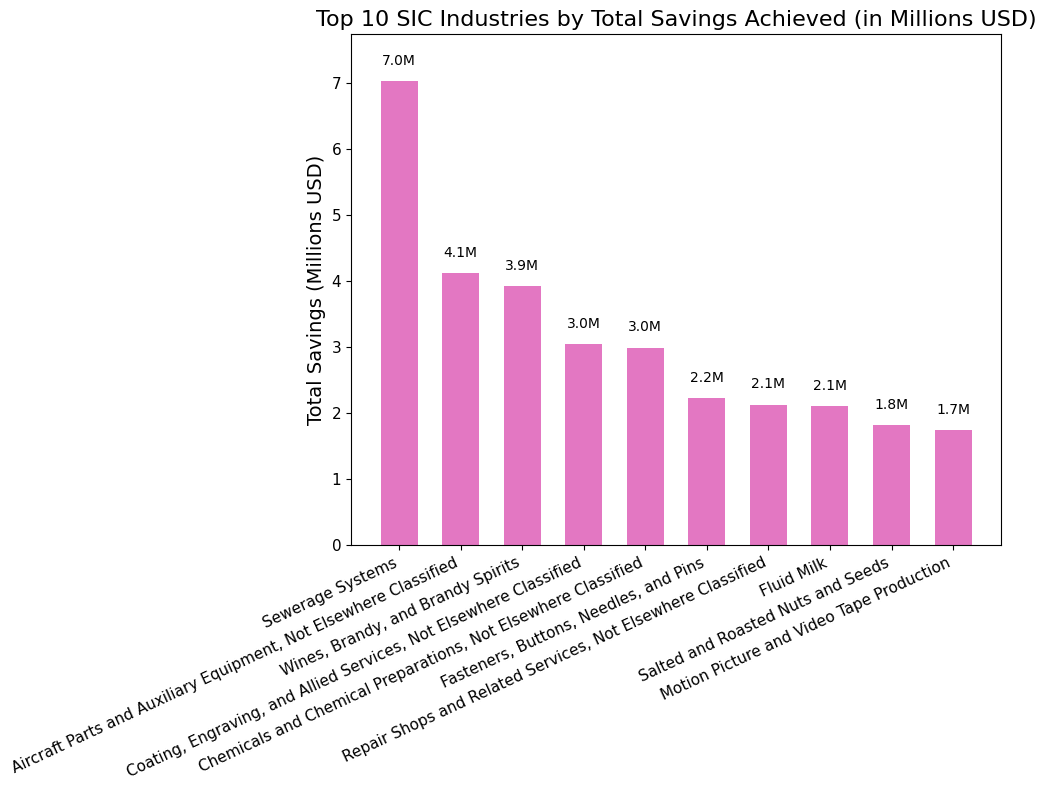

In [ ]:
sic_aggregated_savings = (
    asses_filtered_with_savings
      .groupby("SIC", as_index=False)   # keep SIC as a column
      .agg(total_savings=("TOTAL_RECC_SAVINGS", "sum")) # sum up the TOTAL_SAVINGS column
)

top10_sic_aggregated_savings = sic_aggregated_savings.sort_values("total_savings", ascending=False).head(10)

top10_sic_aggregated_savings_joined_sic = top10_sic_aggregated_savings.merge(sic_lookup, on="SIC", how="left")
top10_sic_aggregated_savings_joined_sic

labels_savings = top10_sic_aggregated_savings_joined_sic["Description"]
savings_m = top10_sic_aggregated_savings_joined_sic["total_savings"] / 1e6  # millions

plt.figure(figsize=(10, 8))
bars_savings = plt.bar(labels_savings, savings_m, color="#E377C2", width=0.6) # Use a different color

# Formatting
plt.title("Top 10 SIC Industries by Total Savings Achieved (in Millions USD)", fontsize=16)
plt.ylabel("Total Savings (Millions USD)", fontsize=14)
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, savings_m.max() * 1.1)  # add a little headroom for annotations

for bar in bars_savings:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.2,                     # slightly above the bar
        f"{h:.1f}M",                 # one decimal place
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
asses_filtered_with_savings["YEAR_ROI"] = asses_filtered_with_savings["TOTAL_RECC_IMP_COST"]/asses_filtered_with_savings["TOTAL_RECC_SAVINGS"]
asses_filtered_with_savings

,ID,CENTER,FY,SIC,NAICS,STATE,SALES,EMPLOYEES,PLANT_AREA,PRODUCTS,PRODUNITS,PRODLEVEL,PRODHOURS,NUMARS,BUILDING_POWER_COSTS,TOTAL_RECC_SAVINGS,TOTAL_RECC_IMP_COST,YEAR_ROI
0,CI0001,CI,2022,3449.0,336413.0,CA,39000000.0,158.0,66336.0,Metal retainer with rubber seals,1.0,1.865530e+05,5616.0,7,583840.00,55078.85,16815.0,0.305290
1,CI0002,CI,2022,3429.0,332999.0,CA,100000000.0,389.0,218600.0,Residential Door Locks and Cabinet Hardware Ac...,1.0,1.000000e+06,3060.0,9,332846.00,104906.09,150582.0,1.435398
2,CI0003,CI,2022,5181.0,488991.0,CA,100000000.0,250.0,573698.0,Beer/Alcohol,1.0,1.000000e+07,7488.0,8,411756.00,154739.00,215926.0,1.395421
3,CI0004,CI,2022,5941.0,451110.0,CA,100000000.0,316.0,180000.0,Outdoor Sporting Goods,NaN,1.000000e+00,4004.0,6,488760.39,87712.00,316222.0,3.605231
4,CI0005,CI,2022,3471.0,332813.0,CA,20000000.0,119.0,30600.0,Metal Finishing,1.0,5.000000e+04,5304.0,10,466502.86,82270.00,77771.0,0.945314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312,SJ0031,SJ,2025,2673.0,326111.0,CA,90000000.0,250.0,200000.0,Flexible Food Packaging,NaN,1.500000e+09,8760.0,4,2926207.00,102250.00,29173.0,0.285311
313,SJ0032,SJ,2025,4952.0,221320.0,CA,100000.0,19.0,220000.0,"Treated Wastewater, Struvite",5.0,7.960000e+05,8760.0,6,726640.00,138440.00,243576.0,1.759434
314,SJ0033,SJ,2025,3679.0,334419.0,CA,65000000.0,171.0,97000.0,Solar combiner boxes and cable harnesses,NaN,3.000000e+04,4680.0,10,422945.00,351380.00,697096.0,1.983881
315,SJ0034,SJ,2025,4941.0,221310.0,CA,1200000.0,3.0,4000.0,Treated water,5.0,1.060000e+05,8760.0,4,105449.00,48900.00,117190.0,2.396524


In [ ]:
asses_filtered_with_savings = asses_filtered_with_savings.merge(
    sic_lookup,
    left_on="SIC",
    right_on="SIC",
    how="left"
)
asses_filtered_with_savings

,ID,CENTER,FY,SIC,NAICS,STATE,SALES,EMPLOYEES,PLANT_AREA,PRODUCTS,...,PRODHOURS,NUMARS,BUILDING_POWER_COSTS,TOTAL_RECC_SAVINGS,TOTAL_RECC_IMP_COST,YEAR_ROI,Division,Major Group,Industry Group,Description
0,CI0001,CI,2022,3449.0,336413.0,CA,39000000.0,158.0,66336.0,Metal retainer with rubber seals,...,5616.0,7,583840.00,55078.85,16815.0,0.305290,D,34,344,Miscellaneous Structural Metal Work
1,CI0002,CI,2022,3429.0,332999.0,CA,100000000.0,389.0,218600.0,Residential Door Locks and Cabinet Hardware Ac...,...,3060.0,9,332846.00,104906.09,150582.0,1.435398,D,34,342,"Hardware, Not Elsewhere Classified"
2,CI0003,CI,2022,5181.0,488991.0,CA,100000000.0,250.0,573698.0,Beer/Alcohol,...,7488.0,8,411756.00,154739.00,215926.0,1.395421,F,51,518,Beer and Ale
3,CI0004,CI,2022,5941.0,451110.0,CA,100000000.0,316.0,180000.0,Outdoor Sporting Goods,...,4004.0,6,488760.39,87712.00,316222.0,3.605231,G,59,594,Sporting Goods Stores and Bicycle Shops
4,CI0005,CI,2022,3471.0,332813.0,CA,20000000.0,119.0,30600.0,Metal Finishing,...,5304.0,10,466502.86,82270.00,77771.0,0.945314,D,34,347,"Electroplating, Plating, Polishing, Anodizing,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312,SJ0031,SJ,2025,2673.0,326111.0,CA,90000000.0,250.0,200000.0,Flexible Food Packaging,...,8760.0,4,2926207.00,102250.00,29173.0,0.285311,D,26,267,"Plastics, Foil, and Coated Paper Bags"
313,SJ0032,SJ,2025,4952.0,221320.0,CA,100000.0,19.0,220000.0,"Treated Wastewater, Struvite",...,8760.0,6,726640.00,138440.00,243576.0,1.759434,E,49,495,Sewerage Systems
314,SJ0033,SJ,2025,3679.0,334419.0,CA,65000000.0,171.0,97000.0,Solar combiner boxes and cable harnesses,...,4680.0,10,422945.00,351380.00,697096.0,1.983881,D,36,367,"Electronic Components, Not Elsewhere Classified"
315,SJ0034,SJ,2025,4941.0,221310.0,CA,1200000.0,3.0,4000.0,Treated water,...,8760.0,4,105449.00,48900.00,117190.0,2.396524,E,49,494,Water Supply


In [ ]:
impCOLS = [
    "ID",
    "CENTER",
    "FY",
    "SIC","NAICS","STATE","SALES","EMPLOYEES","PLANT_AREA","PRODUCTS",
    "BUILDING_POWER_COSTS",
    "TOTAL_RECC_SAVINGS",
    "TOTAL_RECC_IMP_COST",
    "Description",
    "YEAR_ROI"
]
asses_filtered_with_savings = asses_filtered_with_savings[impCOLS]

In [ ]:
asses_filtered_with_savings

,ID,CENTER,FY,SIC,NAICS,STATE,SALES,EMPLOYEES,PLANT_AREA,PRODUCTS,BUILDING_POWER_COSTS,TOTAL_RECC_SAVINGS,TOTAL_RECC_IMP_COST,Description,YEAR_ROI
0,CI0001,CI,2022,3449.0,336413.0,CA,39000000.0,158.0,66336.0,Metal retainer with rubber seals,583840.00,55078.85,16815.0,Miscellaneous Structural Metal Work,0.305290
1,CI0002,CI,2022,3429.0,332999.0,CA,100000000.0,389.0,218600.0,Residential Door Locks and Cabinet Hardware Ac...,332846.00,104906.09,150582.0,"Hardware, Not Elsewhere Classified",1.435398
2,CI0003,CI,2022,5181.0,488991.0,CA,100000000.0,250.0,573698.0,Beer/Alcohol,411756.00,154739.00,215926.0,Beer and Ale,1.395421
3,CI0004,CI,2022,5941.0,451110.0,CA,100000000.0,316.0,180000.0,Outdoor Sporting Goods,488760.39,87712.00,316222.0,Sporting Goods Stores and Bicycle Shops,3.605231
4,CI0005,CI,2022,3471.0,332813.0,CA,20000000.0,119.0,30600.0,Metal Finishing,466502.86,82270.00,77771.0,"Electroplating, Plating, Polishing, Anodizing,...",0.945314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312,SJ0031,SJ,2025,2673.0,326111.0,CA,90000000.0,250.0,200000.0,Flexible Food Packaging,2926207.00,102250.00,29173.0,"Plastics, Foil, and Coated Paper Bags",0.285311
313,SJ0032,SJ,2025,4952.0,221320.0,CA,100000.0,19.0,220000.0,"Treated Wastewater, Struvite",726640.00,138440.00,243576.0,Sewerage Systems,1.759434
314,SJ0033,SJ,2025,3679.0,334419.0,CA,65000000.0,171.0,97000.0,Solar combiner boxes and cable harnesses,422945.00,351380.00,697096.0,"Electronic Components, Not Elsewhere Classified",1.983881
315,SJ0034,SJ,2025,4941.0,221310.0,CA,1200000.0,3.0,4000.0,Treated water,105449.00,48900.00,117190.0,Water Supply,2.396524
